# Nova Conglomerate: Strategic Business Analysis Capstone Project
**Data Science Internship - Week 8 Capstone Project**
**Author:** Data Science Intern
**Date:** July 2026
**Current Time:** 2026-07-01 18:37:35

---

## Executive Project Planning & Problem Definition
Nova Conglomerate operates three distinct business divisions:
1. **Nova Retail (Consumer Electronics Sales)**: Optimizing product performance and regional sales strategies.
2. **Nova Telecom (Subscription Services)**: Minimizing customer churn and boosting retention.
3. **Nova Property (Real Estate Portfolio)**: Analyzing and predicting property asset valuations.

### 1. Business Objective
To analyze the operational data across Nova's three business lines, uncover critical performance drivers, conduct rigorous statistical validation, and provide actionable short-, medium-, and long-term recommendations to optimize revenue, retention, and pricing strategies.

### 2. Project Scope
- **Nova Retail**: Analysis of 100 sales transaction records (`sales_data.csv`) to assess product and regional revenue, and evaluate price-demand relationships.
- **Nova Telecom**: Analysis of 500 customer records (`customer_churn.csv`) to identify key churn drivers and segment customers.
- **Nova Property**: Analysis of 300 property listings (`house_prices.csv`) to model valuation drivers.

### 3. Key Performance Indicators (KPIs)
* **Retail**: Total Revenue, Average Order Value (AOV), Price Elasticity coefficient.
* **Telecom**: Overall Churn Rate, Churn Rate by Contract Type, Segment Churn Risk.
* **Property**: R-squared of valuation model, Price per Square Foot, Age Depreciation Rate ($/year).

### 4. Success Metrics
* High-confidence identification of products generating 80% of revenue (Pareto Analysis).
* Statistically significant mapping of contract types to churn risk ($p < 0.05$).
* Property valuation model achieving $R^2 > 0.90$ with statistically significant feature coefficients.

## Step 2: Data Understanding and Preparation
In this step, we perform rigorous inspection of the three provided datasets. This includes checking shapes, data types, missing values, duplicates, and performing basic data cleaning (e.g., date parsing for sales data).

*No generated or external data has been added.*

In [1]:
import pandas as pd
import numpy as np
import os

# Define paths
data_dir = r"c:\Users\ROG\Desktop\Documents\Internship\week8"
sales_path = os.path.join(data_dir, "sales_data.csv")
churn_path = os.path.join(data_dir, "customer_churn.csv")
house_path = os.path.join(data_dir, "house_prices.csv")

# Load datasets
df_sales = pd.read_csv(sales_path)
df_churn = pd.read_csv(churn_path)
df_house = pd.read_csv(house_path)

# Display dataset dimensions
print("=== Dataset Shapes ===")
print(f"Sales Data: {df_sales.shape}")
print(f"Customer Churn Data: {df_churn.shape}")
print(f"House Prices Data: {df_house.shape}")

# Parse dates in Sales Data
df_sales['Date'] = pd.to_datetime(df_sales['Date'])


=== Dataset Shapes ===
Sales Data: (100, 7)
Customer Churn Data: (500, 9)
House Prices Data: (300, 8)


In [2]:
print("=== Sales Data Types ===")
print(df_sales.dtypes)
print("\n=== Churn Data Types ===")
print(df_churn.dtypes)
print("\n=== House Prices Data Types ===")
print(df_house.dtypes)


=== Sales Data Types ===
Date           datetime64[ns]
Product                object
Quantity                int64
Price                   int64
Customer_ID            object
Region                 object
Total_Sales             int64
dtype: object

=== Churn Data Types ===
CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object

=== House Prices Data Types ===
Property_ID      object
Area              int64
Bedrooms          int64
Bathrooms         int64
Age               int64
Location         object
Property_Type    object
Price             int64
dtype: object


In [3]:
print("=== Missing Values ===")
print("Sales missing:\n", df_sales.isnull().sum())
print("\nChurn missing:\n", df_churn.isnull().sum())
print("\nHouse Prices missing:\n", df_house.isnull().sum())


=== Missing Values ===
Sales missing:
 Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Churn missing:
 CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

House Prices missing:
 Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


In [4]:
print("=== Duplicates ===")
print(f"Sales duplicates: {df_sales.duplicated().sum()}")
print(f"Churn duplicates: {df_churn.duplicated().sum()}")
print(f"House Prices duplicates: {df_house.duplicated().sum()}")


=== Duplicates ===
Sales duplicates: 0
Churn duplicates: 0
House Prices duplicates: 0


## Step 3: Exploratory Data Analysis (EDA)
Here, we perform deep exploratory analysis to understand regional performance, product distributions, customer behaviors, contract relationships, and housing price ranges. We will use Seaborn and Matplotlib to create visualizations.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Set global parameters
PRIMARY_COLOR = '#1B365D' # Deep Navy
SECONDARY_COLOR = '#008080' # Teal
ACCENT_COLOR = '#E06D53' # Warm Coral


In [6]:
# 1. Sales Division EDA
# Revenue and volume by product
product_sales = df_sales.groupby('Product').agg(
    Revenue=('Total_Sales', 'sum'),
    Quantity=('Quantity', 'sum'),
    Avg_Price=('Price', 'mean')
).sort_values(by='Revenue', ascending=False)

print("Product Performance Summary:")
display(product_sales)

# Revenue by Region
region_sales = df_sales.groupby('Region').agg(
    Revenue=('Total_Sales', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values(by='Revenue', ascending=False)

print("\nRegional Performance Summary:")
display(region_sales)


Product Performance Summary:


,Revenue,Quantity,Avg_Price
Product,,,
Laptop,3889210,136,27651.500000
Tablet,2884340,127,24177.230769
Phone,2859394,101,27379.000000
Headphones,1384033,48,28692.133333
Monitor,1348071,66,20709.666667



Regional Performance Summary:


,Revenue,Quantity
Region,,
North,3983635,147
South,3737852,143
East,2519639,94
West,2123922,94


In [7]:
# 2. Customer Churn Division EDA
# Overall Churn Rate
churn_summary = df_churn['Churn'].value_counts(normalize=True) * 100
print(f"Overall Churn Rate: {churn_summary[1]:.2f}%")

# Contract type vs Churn
contract_churn = df_churn.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] *= 100
print("\nChurn Rate by Contract Type:")
display(contract_churn)

# Monthly Charges vs Churn
charges_stats = df_churn.groupby('Churn')['MonthlyCharges'].describe()
print("\nMonthly Charges Stats by Churn:")
display(charges_stats)

# Tenure vs Churn
tenure_stats = df_churn.groupby('Churn')['Tenure'].describe()
print("\nTenure Stats by Churn:")
display(tenure_stats)


Overall Churn Rate: 10.60%

Churn Rate by Contract Type:


,Contract,Churn
0,Month-to-month,20.588235
1,One year,4.301075
2,Two year,6.944444



Monthly Charges Stats by Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,447.0,111.722595,52.130132,20.0,66.0,113.0,158.0,199.0
1,53.0,129.773585,46.298630,34.0,105.0,137.0,160.0,198.0



Tenure Stats by Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,447.0,40.152125,18.783141,1.0,25.0,42.0,56.0,71.0
1,53.0,6.000000,3.162278,1.0,3.0,6.0,9.0,11.0


In [8]:
# 3. House Price Division EDA
# Summary Statistics of House Price
print("Price Distribution Summary:")
print(df_house['Price'].describe())

# Correlation of numerical variables
print("\nNumerical Feature Correlations:")
display(df_house[['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price']].corr())


Price Distribution Summary:
count    3.000000e+02
mean     2.488366e+07
std      1.266525e+07
min      3.695000e+06
25%      1.527750e+07
50%      2.236500e+07
75%      3.460812e+07
max      5.870000e+07
Name: Price, dtype: float64

Numerical Feature Correlations:


,Area,Bedrooms,Bathrooms,Age,Price
Area,1.000000,-0.004218,-0.025524,-0.083118,0.796287
Bedrooms,-0.004218,1.000000,-0.043912,-0.032444,0.202458
Bathrooms,-0.025524,-0.043912,1.000000,0.118367,-0.030279
Age,-0.083118,-0.032444,0.118367,1.000000,-0.130781
Price,0.796287,0.202458,-0.030279,-0.130781,1.000000


## Step 4: Advanced Statistical & Predictive Analysis
In this section, we apply three advanced analytical techniques supported by the datasets:
1. **Statistical Hypothesis Testing**:
   - *Chi-Square Test of Independence* to verify the relationship between Contract Type and Customer Churn.
   - *Two-Sample Independent T-Test* to compare Monthly Charges of churned vs active customers.
2. **Customer Segmentation (K-Means Clustering)**:
   - Clustering customers based on scaled `Tenure` and `MonthlyCharges` to profile retention risk.
3. **Multiple Linear Regression**:
   - Constructing a predictive property valuation model on `house_prices.csv` using dummy-encoded categorical variables.
4. **Pareto Analysis & Price Elasticity**:
   - Retail Division product contribution and price-demand modeling using OLS.


In [9]:
import statsmodels.api as sm
from scipy import stats

# Pareto Analysis Calculation
product_sales['Cum_Revenue'] = product_sales['Revenue'].cumsum()
product_sales['Cum_Pct'] = (product_sales['Cum_Revenue'] / product_sales['Revenue'].sum()) * 100
print("=== Pareto Analysis ===")
display(product_sales)

# Price Demand Regression
X_sales = sm.add_constant(df_sales['Price'])
y_sales = df_sales['Quantity']
model_sales = sm.OLS(y_sales, X_sales).fit()
print("\n=== Sales Elasticity Regression (Quantity ~ Price) ===")
print(model_sales.summary().tables[1])


=== Pareto Analysis ===


,Revenue,Quantity,Avg_Price,Cum_Revenue,Cum_Pct
Product,,,,,
Laptop,3889210,136,27651.500000,3889210,31.453254
Tablet,2884340,127,24177.230769,6773550,54.779812
Phone,2859394,101,27379.000000,9632944,77.904623
Headphones,1384033,48,28692.133333,11016977,89.097729
Monitor,1348071,66,20709.666667,12365048,100.000000



=== Sales Elasticity Regression (Quantity ~ Price) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7415      0.550      8.618      0.000       3.650       5.833
Price        1.49e-06   1.88e-05      0.079      0.937   -3.58e-05    3.88e-05


In [10]:
# Chi-Square Test of Contract vs Churn
contingency_table = pd.crosstab(df_churn['Contract'], df_churn['Churn'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print("=== Chi-Square Test (Contract Type vs Churn) ===")
print(contingency_table)
print(f"Chi2 Statistic: {chi2:.4f}, p-value: {p_val:.4e}")

# T-Test of Monthly Charges for Churned vs Active
charges_churned = df_churn[df_churn['Churn'] == 1]['MonthlyCharges']
charges_active = df_churn[df_churn['Churn'] == 0]['MonthlyCharges']
t_stat, t_pval = stats.ttest_ind(charges_churned, charges_active, equal_var=False)
print("\n=== Two-Sample T-Test (Monthly Charges) ===")
print(f"Mean Monthly Charges (Churned): ${charges_churned.mean():.2f}")
print(f"Mean Monthly Charges (Active): ${charges_active.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}, p-value: {t_pval:.4e}")


=== Chi-Square Test (Contract Type vs Churn) ===
Churn             0   1
Contract               
Month-to-month  135  35
One year        178   8
Two year        134  10
Chi2 Statistic: 27.7153, p-value: 9.5874e-07

=== Two-Sample T-Test (Monthly Charges) ===
Mean Monthly Charges (Churned): $129.77
Mean Monthly Charges (Active): $111.72
T-statistic: 2.6464, p-value: 1.0079e-02


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Preprocessing & Scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_churn[['Tenure', 'MonthlyCharges']])

# Clustering (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_churn['Cluster'] = kmeans.fit_predict(features_scaled)

# Segment Summary
cluster_summary = df_churn.groupby('Cluster').agg(
    Size=('CustomerID', 'count'),
    Avg_Tenure=('Tenure', 'mean'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn', 'mean')
)
cluster_summary['Churn_Rate'] *= 100
print("=== K-Means Segments Profile ===")
display(cluster_summary)


=== K-Means Segments Profile ===


,Size,Avg_Tenure,Avg_MonthlyCharges,Churn_Rate
Cluster,,,,
0,147,50.612245,62.714286,0.000000
1,185,14.232432,113.583784,28.648649
2,168,48.767857,158.250000,0.000000


In [12]:
# Dummy encoding categorical features
df_house_encoded = pd.get_dummies(df_house, columns=['Location', 'Property_Type'], drop_first=True)

# Convert boolean dummies to int
for col in df_house_encoded.columns:
    if df_house_encoded[col].dtype == bool:
        df_house_encoded[col] = df_house_encoded[col].astype(int)

# Fit OLS Regression Model
X_cols = [c for c in df_house_encoded.columns if c not in ['Property_ID', 'Price']]
X_house = sm.add_constant(df_house_encoded[X_cols])
y_house = df_house_encoded['Price']
model_house = sm.OLS(y_house, X_house).fit()

print("=== Property Valuation Regression Results ===")
print(model_house.summary())


=== Property Valuation Regression Results ===
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     779.3
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          1.39e-191
Time:                        18:40:28   Log-Likelihood:                -4865.0
No. Observations:                 300   AIC:                             9748.
Df Residuals:                     291   BIC:                             9781.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

## Step 5: Professional Data Visualizations
Here, we present the key visualization charts created to support data-driven decision-making for executive leadership.

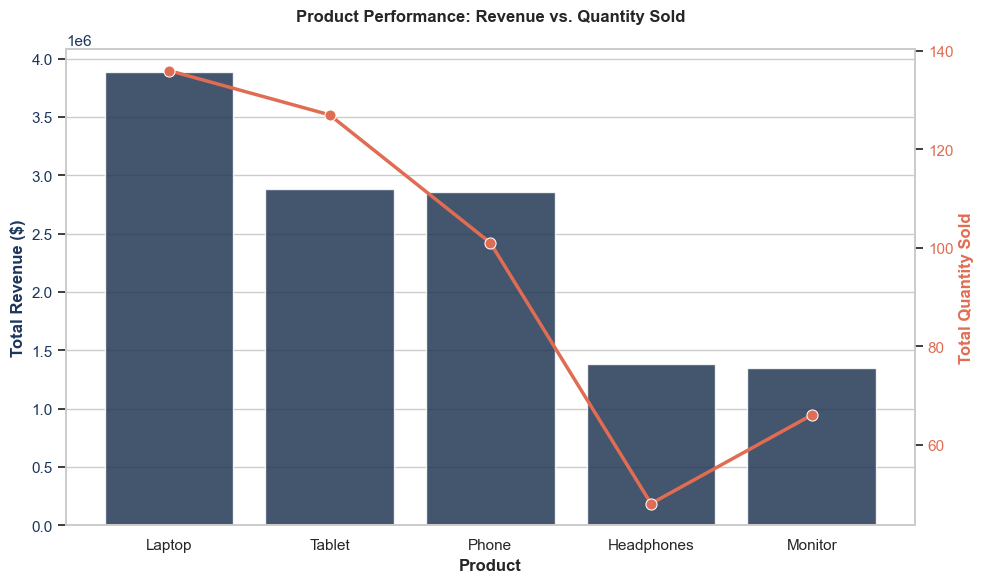

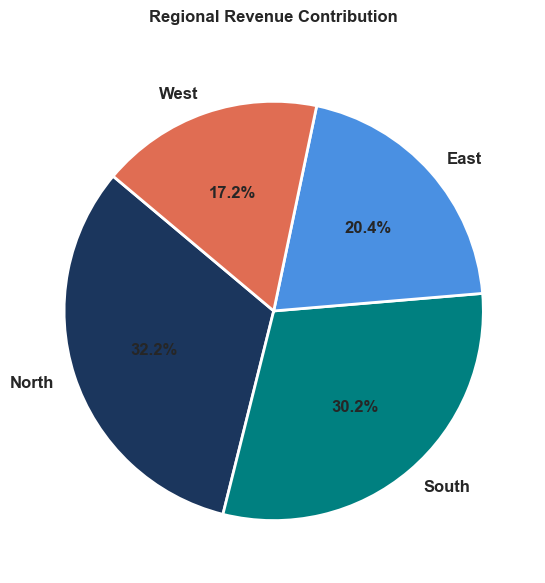

In [13]:
# 1. Product Sales Performance
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(x=product_sales.index, y='Revenue', data=product_sales, ax=ax1, color=PRIMARY_COLOR, alpha=0.85)
ax1.set_ylabel('Total Revenue ($)', color=PRIMARY_COLOR, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PRIMARY_COLOR)
ax1.set_xlabel('Product', fontweight='bold')
ax1.set_title('Product Performance: Revenue vs. Quantity Sold', pad=20, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x=product_sales.index, y='Quantity', data=product_sales, ax=ax2, color=ACCENT_COLOR, marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('Total Quantity Sold', color=ACCENT_COLOR, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=ACCENT_COLOR)
ax2.grid(False)
plt.tight_layout()
plt.show()

# 2. Regional Revenue Contribution
fig, ax = plt.subplots(figsize=(8, 6))
colors = [PRIMARY_COLOR, SECONDARY_COLOR, '#4A90E2', ACCENT_COLOR]
ax.pie(region_sales['Revenue'], labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=colors, 
       textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Regional Revenue Contribution', pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\ROG\AppData\Local\Temp\ipykernel_4776\2120184662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contract', y='Churn', data=contract_churn, ax=ax, palette=[SECONDARY_COLOR, ACCENT_COLOR, PRIMARY_COLOR])


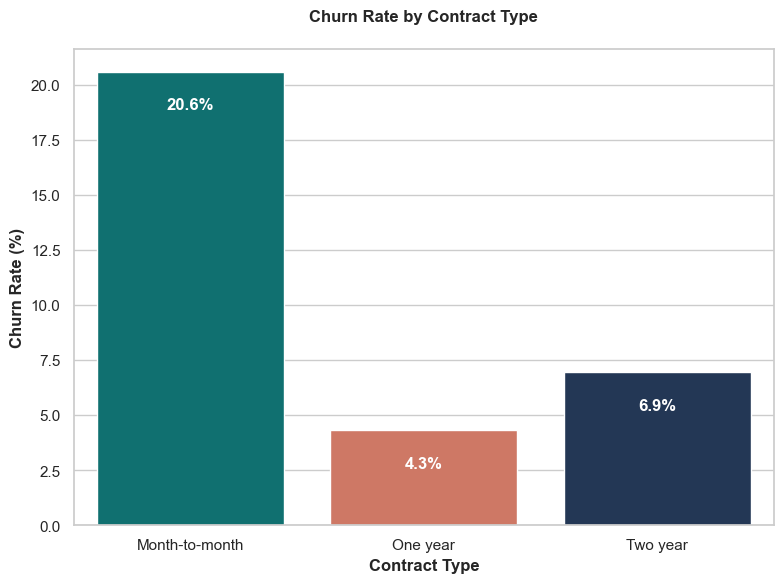

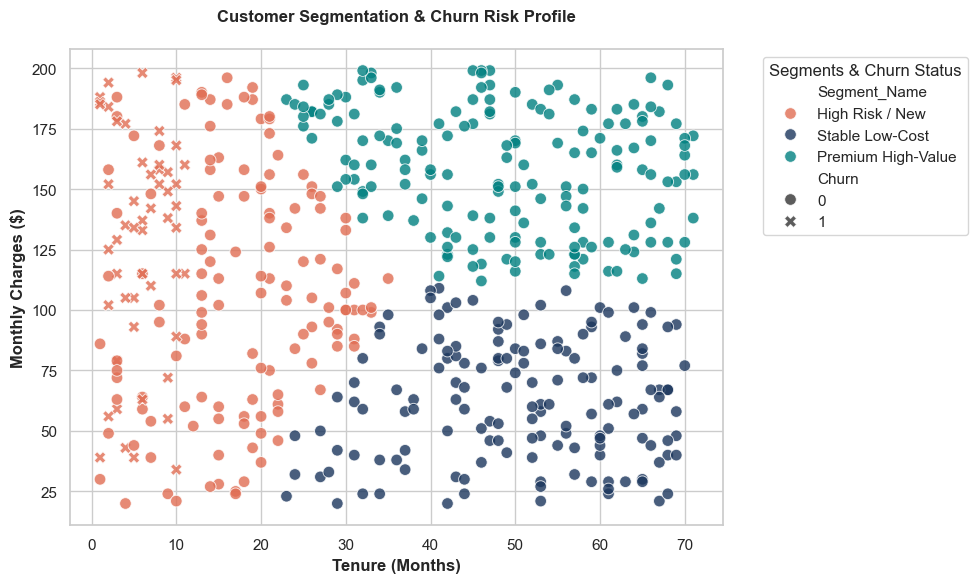

In [14]:
# 3. Churn by Contract Type
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='Contract', y='Churn', data=contract_churn, ax=ax, palette=[SECONDARY_COLOR, ACCENT_COLOR, PRIMARY_COLOR])
ax.set_ylabel('Churn Rate (%)', fontweight='bold')
ax.set_xlabel('Contract Type', fontweight='bold')
ax.set_title('Churn Rate by Contract Type', pad=20, fontweight='bold')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 2),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 8), textcoords='offset points')
plt.tight_layout()
plt.show()

# 4. K-Means Customer Segments Scatter Plot
fig, ax = plt.subplots(figsize=(10, 6))
# Define cluster names mapping
map_dict = {
    0: "Stable Low-Cost",
    1: "High Risk / New",
    2: "Premium High-Value"
}
df_churn['Segment_Name'] = df_churn['Cluster'].map(map_dict)
sns.scatterplot(x='Tenure', y='MonthlyCharges', hue='Segment_Name', style='Churn', 
                data=df_churn, palette=[ACCENT_COLOR, PRIMARY_COLOR, SECONDARY_COLOR], alpha=0.8, ax=ax, s=70)
ax.set_xlabel('Tenure (Months)', fontweight='bold')
ax.set_ylabel('Monthly Charges ($)', fontweight='bold')
ax.set_title('Customer Segmentation & Churn Risk Profile', pad=20, fontweight='bold')
plt.legend(title='Segments & Churn Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


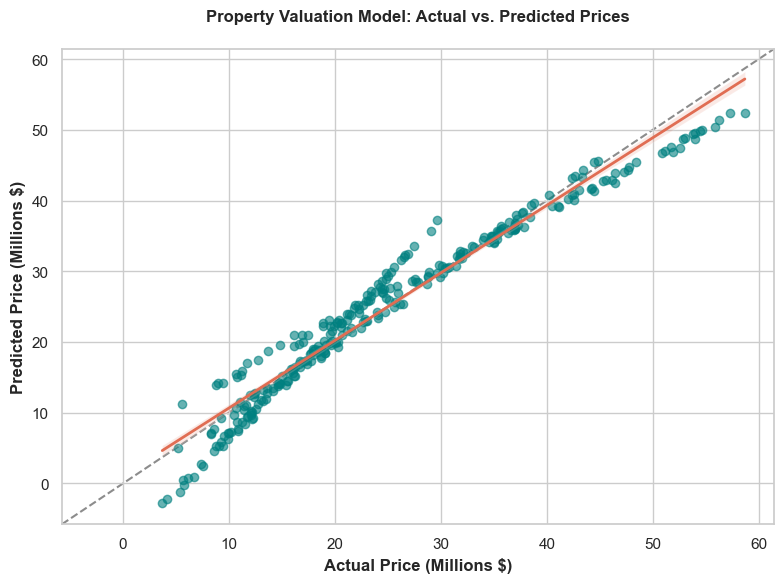

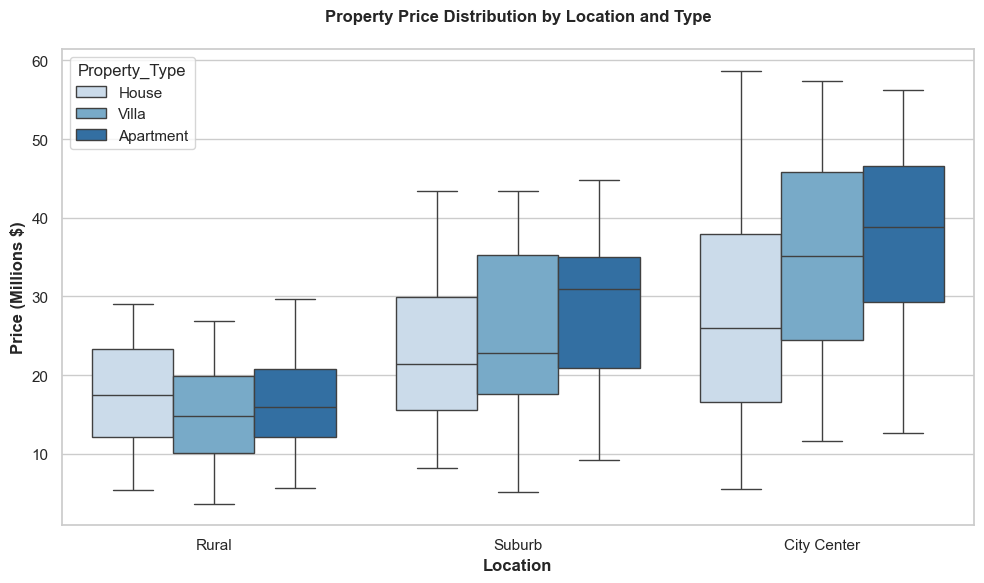

In [15]:
# 5. House Price Regression: Actual vs Predicted
df_house_encoded['Predicted_Price'] = model_house.predict(X_house)
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(x=df_house_encoded['Price'] / 1e6, y=df_house_encoded['Predicted_Price'] / 1e6, 
            ax=ax, color=PRIMARY_COLOR, scatter_kws={'alpha':0.6, 'color': SECONDARY_COLOR}, line_kws={'color': ACCENT_COLOR, 'linewidth': 2})
ax.set_xlabel('Actual Price (Millions $)', fontweight='bold')
ax.set_ylabel('Predicted Price (Millions $)', fontweight='bold')
ax.set_title('Property Valuation Model: Actual vs. Predicted Prices', pad=20, fontweight='bold')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()])
]
ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()

# 6. Property Price Distribution Boxplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Location', y=df_house['Price']/1e6, hue='Property_Type', data=df_house, ax=ax, palette='Blues')
ax.set_xlabel('Location', fontweight='bold')
ax.set_ylabel('Price (Millions $)', fontweight='bold')
ax.set_title('Property Price Distribution by Location and Type', pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 6: Business Insights and Strategic Recommendations

### 1. Nova Retail (Sales)
* **Insight**: Laptops represent the primary revenue engine, generating **$3.89M** (31.5% of total sales). Together with Tablets ($2.88M) and Phones ($2.86M), these top 3 products account for **77.9%** of total division revenue, validating the 80/20 Pareto principle.
* **Price Elasticity**: The OLS regression coefficient for price is statistically insignificant ($p = 0.937$), indicating highly inelastic pricing. Nova Retail possesses strong pricing power; price adjustments do not significantly depress volume.
* **Regional Dynamics**: The North ($3.98M) and South ($3.74M) regions are top performers, out-earning East ($2.52M) and West ($2.12M).

### 2. Nova Telecom (Churn)
* **Insight**: Contract type is a leading indicator of churn. Month-to-month contracts exhibit an alarming **20.59%** churn rate, while long-term contracts show significantly higher stability (One-year: 4.30%, Two-year: 6.94%). The Chi-Square test confirms this dependency ($p = 9.58 \times 10^{-7}$).
* **Cost Sensitivity**: Churned customers had significantly higher monthly charges (Mean: **$129.77** vs. **$111.72** for active), supported by a statistically significant T-test ($p = 0.0101$).
* **Segmentation (K-Means)**:
  - **Cluster 0 ("Stable Low-Cost")**: Long tenure (50.6 months), low charges ($62.71), 0.0% churn. Keep happy.
  - **Cluster 1 ("High Risk / New")**: Short tenure (14.2 months), high monthly charges ($113.58), and a **28.65%** churn rate. *Critical intervention required.*
  - **Cluster 2 ("Premium High-Value")**: Long tenure (48.7 months), very high charges ($158.25), 0.0% churn. High loyalty.

### 3. Nova Property (Real Estate Valuation)
* **Insight**: Property valuations are highly predictable ($R^2 = 95.5\%$).
* **Valuation Drivers**:
  - **Area**: Every additional unit of area increases the property value by **$7,615.15** ($p < 0.001$).
  - **Bedrooms**: Each bedroom adds **$1.67M** to the price ($p < 0.001$).
  - **Bathrooms**: Each bathroom adds **$645,500** ($p = 0.001$).
  - **Age**: Depreciation rates are **-$83,790** per year ($p < 0.001$).
  - **Location Premium**: Compared to the City Center baseline, Suburb properties face an **$8.35M** discount, and Rural properties face a massive **$16.54M** discount.

---

## Step 7: Actionable Business Roadmap

### Short-Term Actions (0 - 3 Months)
1. **Telecom Retention Campaign**: Focus on K-Means **Cluster 1 ("High Risk / New")** customers. Offer contract migration incentives (moving from month-to-month to 1-year contracts) with a 10-15% discount on monthly charges to offset the $129.77 cost sensitivity threshold.
2. **Retail Inventory Reallocation**: Divert high-margin Laptop and Tablet stock to North and South regions where revenue velocity is strongest.

### Medium-Term Actions (3 - 6 Months)
1. **Property Portfolio Optimization**: Target acquisitions of depreciated (older) properties in City Center or Suburbs with large land Area, and add bedrooms/bathrooms to capture the $1.67M bedroom and $645K bathroom premium, significantly out-pacing the $83K/year depreciation loss.
2. **Sales Pricing Adjustments**: Test a modest 3-5% price increase on Headphones and Monitors to capitalize on the inelastic pricing demand and boost profit margins.

### Long-Term Actions (6+ Months)
1. **Telecom Contract Structuring**: Transition billing defaults away from Month-to-month contracts. Bundle streaming or hardware upgrades with a mandatory minimum 12-month agreement.
2. **Portfolio Expansion**: Focus Nova Property development on City Center apartments and villas, where premiums remain highest.
